# Introduction

In this notebook, we take notes and recreate the results in Section 2 and 3 of Daniele Boffi's Finite element approximation of eigenvalue problems.

In patricular, we explore the Laplace eigenvalue problem in one and two dimensions. To do so, we start with the 1D problem with CG1 elements and perform a convergence test to confirm the quadratic convergence in the computed eigenvalues. Then, in 2D, we explore CG1 elements on sequences of unstructured square meshes, structured square meshes, structured square meshes with reversed diagonals, structured square meshes with criss-crossed squares, and unstructured L-shaped meshes. We then explore the impact of nonconforming elements, namely, the Crouzeix-Raviart elements (CR).

To explore different behvaiour of eigenvalues, such as spurious solutions, we rewrite the Laplace eigenvalue problem in mixed form (coming soon).

#### Maggie McC, May 2026.



In [1]:
# install firedrake

# hide output
%%capture


try:
    from firedrake import *
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    from firedrake import *

In [2]:
# gmsh

%%capture
try:
    import gmsh
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/gmsh-install.sh" -O "/tmp/gmsh-install.sh" && bash "/tmp/gmsh-install.sh"
    import gmsh

In [3]:
# netgen

%%capture
try:
    import ngsolve
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/ngsolve-install-release-real.sh" -O "/tmp/ngsolve-install.sh" && bash "/tmp/ngsolve-install.sh"
    import ngsolve

In [4]:
import numpy as np
from firedrake import *
import gmsh
import matplotlib.pyplot as plt
from firedrake.pyplot import tripcolor, triplot, tricontourf, tricontour, trisurf
from scipy.spatial import Delaunay
import pandas as pd
from netgen.occ import WorkPlane, Axes, OCCGeometry, X, Z

# 1D Laplace Eigenvalue Problem

Consider $\Omega = (0, \pi).$ We want to find the eigenvalues, $\lambda,$ and the eigenfunctions, $u \ne 0,$ such that
$$ -u''(x) = \lambda u(x), \qquad \text{for} \qquad x \in \Omega,$$
where,
$$ u(0)=u(\pi) = 0.$$

It is well-known that $\lambda = 1, 4, 9, 16, \dots$ and $u(x) = \sin(kx)$ for $k=1,2,3,\dots.$

## Variational Problem

Let $V = H_0^1(\Omega).$ To construct the variational formulation we multiply by a $v \in V$ and integrate by parts. Upon doing so, we obtain:
"Find $\lambda \in \mathbb{R}$ and a nonvanishing $u \in V$ such that
$$ \int_{0}^{\pi} u'(x) v'(x) \, dx = \lambda \, \int_0^{\pi} u(x) v(x) \, dx $$
for all $v \in V.$"

## Galerkin approximation

To discretize the infinite-dimensional problem we consider a finite-dimensional subspace, $V_h = \text{span}\{\phi_1, \phi_2, \dots, \phi_N\} \subset V.$ Then, in this subspace, we look for discrete eigenvalues, $\lambda_h \in \mathbb{R}$ and nonvanishing eigenfunctions $u_h \in \mathbb{R}$ such that
$$ \int_{0}^{\pi} u_h'(x) v'(x) \, dx = \lambda_h \, \int_0^{\pi} u_h(x) v_h(x) \, dx $$
for all $v \in V_h.$

Using the basis for $V_h,$ the discrete variational problem can be written as the generalized eigenvalue problem
$$ Ax = \lambda M x, $$
Here, the stiffness matrix is $A = \{a_{ij}\}_{i,j}^N,$ where,
$$
a_{ij}
=
\int_0^\pi \varphi_j'(x)\varphi_i'(x)\,dx
$$
Similarly, the mass matrix is $M = \{m_{ij}\}_{i,j}^N,$ where
$$
m_{ij}
=
\int_0^\pi \varphi_j(x)\varphi_i(x)\,dx
$$


## $P^1$ elements

Take a uniform partition of $[0, \pi]$ with spacing $h.$ Let $V_h$ be the space of continuous piecewise linear polynomials vanishing at the endpoints of the interval (standard conforming $P^1$ elements). The, the associated stiffness and mass matrices are
$$
a_{ij}
=
\frac{1}{h}
\begin{cases}
2, & i=j,\\
-1, & |i-j|=1,\\
0, & \text{otherwise},
\end{cases}
\qquad
m_{ij}
=
h
\begin{cases}
4/6, & i=j,\\
1/6, & |i-j|=1,\\
0, & \text{otherwise},
\end{cases}
$$
respectively.

In this case, we can compute the explicit eigenmodes. In particular, given a $k \in \mathbb{N},$ the $k$th eigenspace is generated by the interpolant of the continuous solution, i.e.,
$$ u_h^{(k)}(ih) = \sin(kih), \qquad i = 1, \dots, N,$$
where the corresponding eigenvalue is
$$ \lambda_h^{(k)} = \frac{6}{h^2} \frac{1 - \cos(kh)}{2 + \cos(kh)}.$$

As is standard for $P^1$ elements with $V = H_0^1(\Omega),$ the expected convergence rate for the eigenmodes is
$$ \| u^{(k)}  - u_h^{(k)} \|_V = O(h),$$
where $u^{(k)}(x) = \sin(kx).$
For the eigenvalues, we recall that $\cos(kh) = 1 - k^2h^2/2 + O(h^4).$ Then,
$$ \lambda_h^{(k)} = \frac{6}{h^2} \frac{1 - \cos(kh)}{2 + \cos(kh)} = \frac{h}{h^2} \frac{ [k^2h^2/2 + O(h^4)] }{[3 - k^2h^2/2 + O(h^4)] } = k^2 + k^4h^2/12 + O(k^6 h^4).$$
Thus,
$$ | \lambda^{(k)} - \lambda_h^{(k)} | = k^4h^2/12 + O(k^6 h^4) = O(k^4 h^2),$$
where $\lambda^{(k)} = k^2.$
This result makes sense; as $k$ increases, the eigenfunctions present more and more oscillations, and an increasingly finer mesh is required to keep the approximation error within the same accuracy.

## Remarks



*   In this setting, the eigenvalues are approximated from above:
$$ \lambda^{(k)} \le \lambda_h^{(k)} \le \lambda^{(k)} + C(k) h^2.$$
*   Since eigenmodes are only unique up to scalar multiples, we need to be careful when computing $\| u^{(k)}  - u_h^{(k)} \|_V.$ To overcomes this issue, we first normalize the computed eigenmode. To overcome any sign discrepencis, we choose the sign to match the sign of $u^{(k)}$ (ensure their scalar product is positive).

## $P^p$ elements

Now, take $V_h$ to be the space of continuous piecewise polynomials of degree at most $p$ that vanish at the endpoints of the interval (standard conforming $P^p$ elements). Then, our convergence results are
$$ \| u^{(k)}  - u_h^{(k)} \|_V = O(h^p)$$
and
$$ | \lambda^{(k)} - \lambda_h^{(k)} | = O(h^{2p}).$$






## Compute 10 eigenvalues and eigenmodes

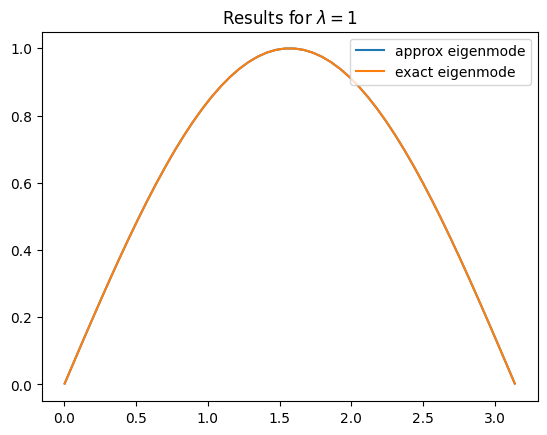

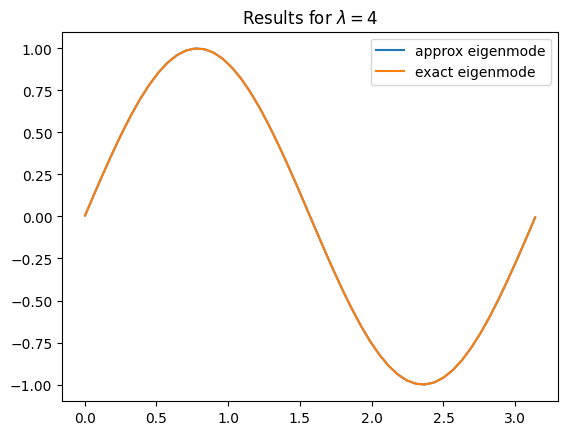

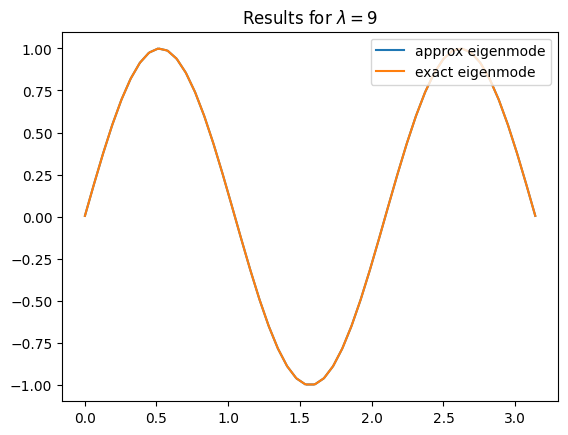

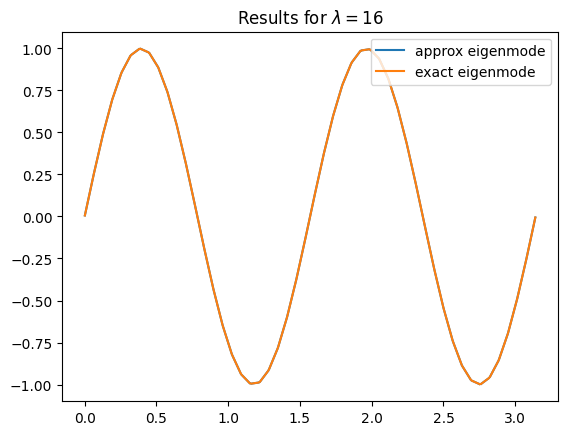

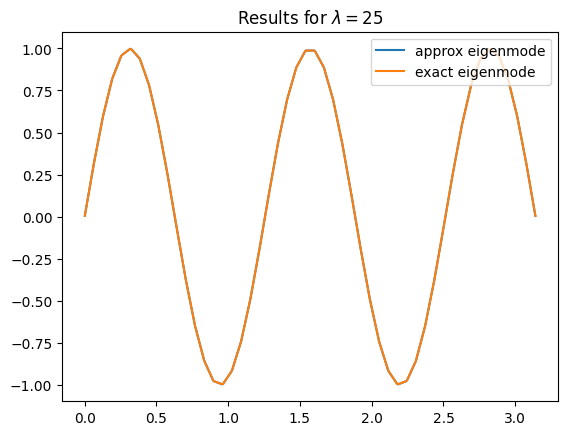

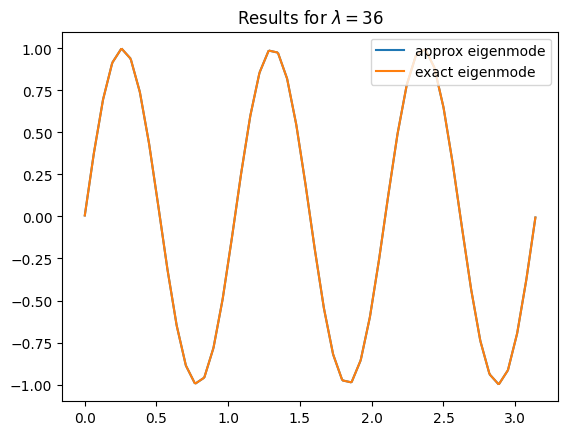

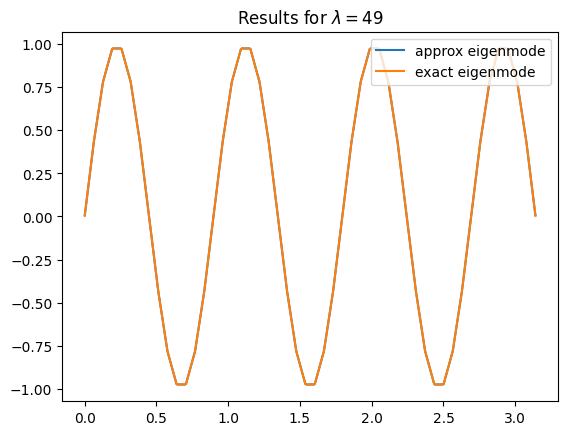

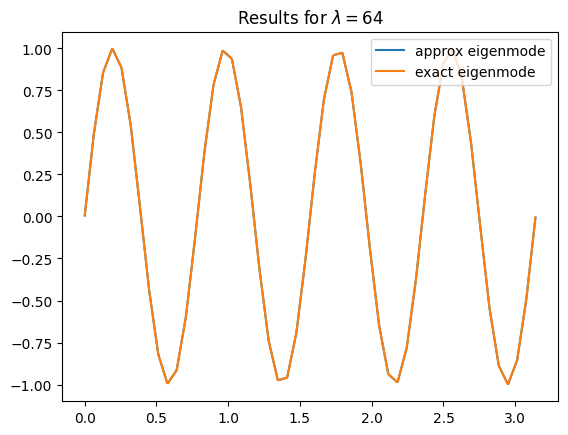

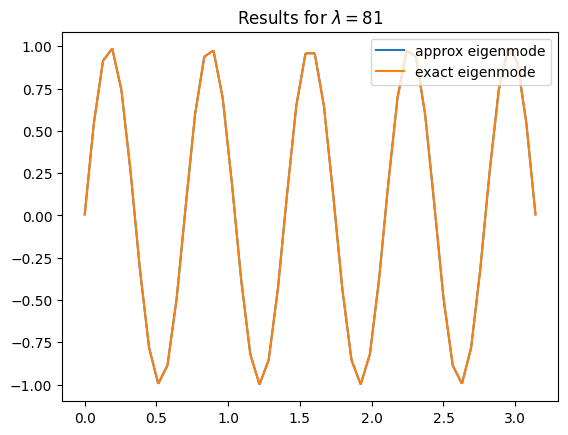

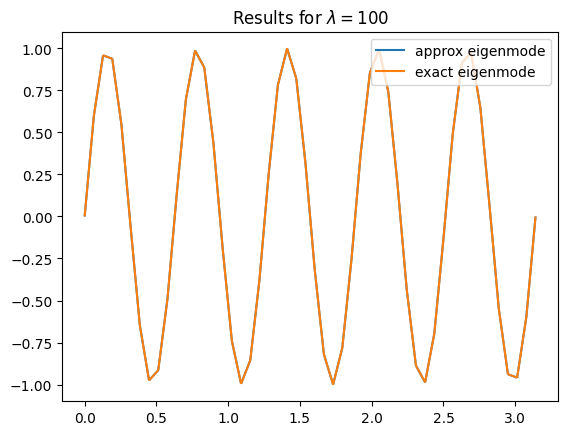

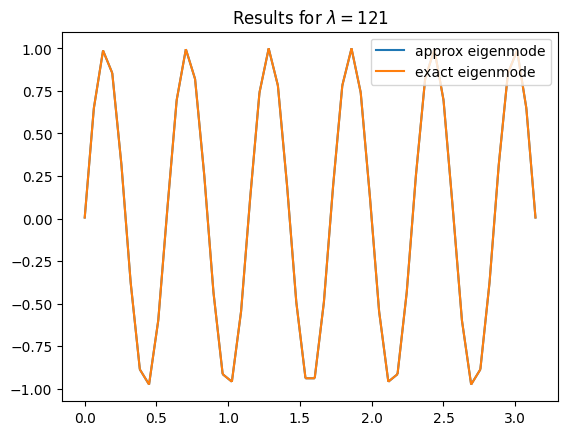

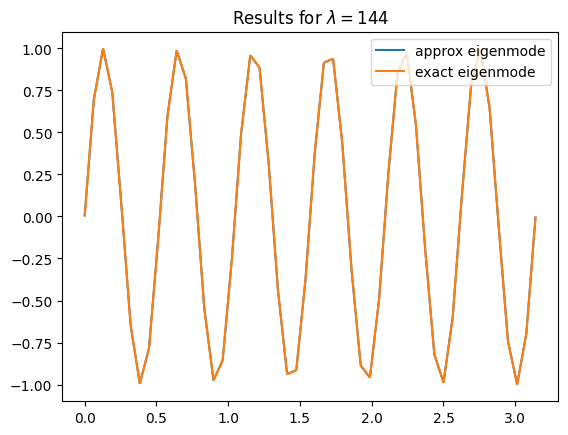

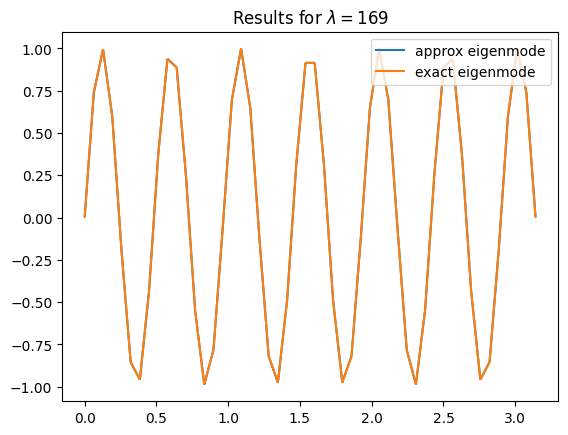

In [5]:
# Set the mesh
N = 49
mesh = IntervalMesh(N, 0, pi)

# Set the weak form
V = FunctionSpace(mesh, 'CG', 1)
x = SpatialCoordinate(mesh)[0]

u = TrialFunction(V)
v = TestFunction(V)

a = inner(grad(u), grad(v))*dx
b = inner(u, v)*dx

# Boundary conditions and problem
bc = DirichletBC(V, 0, "on_boundary")
eigenproblem = LinearEigenproblem(a, b, bc)

# Set the solver
sp = {
          "eps_gen_hermitian": None,  # kind of problem
          "eps_smallest_real": None,  # which eigenvalues
          "eps_type": "krylovschur",  # algorithm
          "eps_target": 0,            # shift parameter
          "st_type": "sinvert",       # shift-and-invert
          }

# Set the solver
eigensolver = LinearEigensolver(eigenproblem, 10, solver_parameters=sp)
nconv = eigensolver.solve()  # number of converged eigenvalues

# Pull out the eigenvalues and eigenfuncs

# Take real part, since we know it is Hermitian
eigenvalues = [eigensolver.eigenvalue(i).real for i in range(nconv)]
# Only take real part; .eigenfunction returns (real, complex)
eigenfuncs  = [eigensolver.eigenfunction(i)[0] for i in range(nconv)]

# Plot

for i in range(nconv):
    uh = eigenfuncs[i]

    # exact mode corresponding to lambda = k^2
    u_ex = Function(V).interpolate(sin((i+1) * x))

    # normalize uh to same L2 norm as uex
    # norm_uh = sqrt(assemble(uh*uh*dx))
    # norm_uex = sqrt(assemble(uex*uex*dx))
    norm_uh = norm(uh)
    norm_uex = norm(u_ex)
    uh.assign((norm_uex / norm_uh) * uh)

    # fix sign of our approx to be the same as our exact soln
    if assemble(uh * u_ex * dx) < 0:
        uh.assign(-uh)


    fig, axes = plt.subplots()
    plot(uh, label="approx eigenmode", axes = axes)
    plot(u_ex, label="exact eigenmode", axes = axes)
    axes.set_title(r"Results for $\lambda = $" + str((i+1)**2))
    axes.legend()
    fig.show()

## Convergence test

  Eigenvalue approximations and residual norms for petsctools_1_ solve.
  1 EPS nconv=10 first unconverged value (error) 133.149 (2.50485439e-09)

The computed eigenvalues are:
[1.0008034482561488, 4.012867497427195, 9.065244863728715, 16.206656720942267, 25.5059230069702, 37.05252222217851, 50.95723003882493, 67.35275917044734, 86.39428520152124, 108.25969024392093]

  Eigenvalue approximations and residual norms for petsctools_2_ solve.
  1 EPS nconv=9 first unconverged value (error) 102.024 (4.09907024e-09)
  2 EPS nconv=12 first unconverged value (error) 174.809 (1.15392914e-10)

The computed eigenvalues are:
[1.0002008137395433, 4.003213793024623, 9.016276338172345, 16.051469989708806, 25.125748953612515, 36.260979454914896, 49.4839893090459, 64.82662688376915, 82.32582837496444, 102.02369202788078, 123.96755759176558, 148.21008888871398]

  Eigenvalue approximations and residual norms for petsctools_3_ solve.
  1 EPS nconv=8 first unconverged value (error) 81.3299 (1.29933927e-10

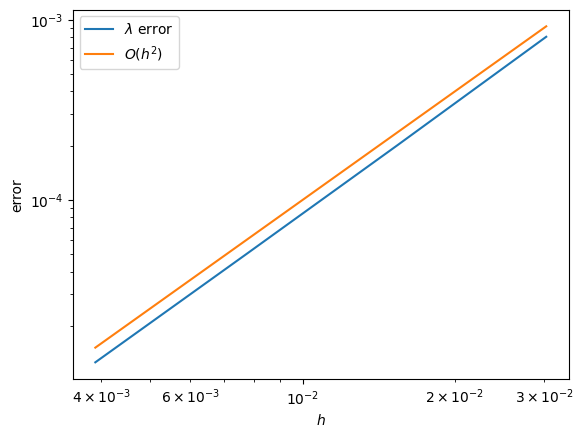


The approx slope is 2.025937245197322


In [6]:
# Convergence Test

# Set N's and error lists
N_vals = [32, 64, 128, 256]
u_errs  = []
l_errs = []

# Set eigensolver
sp = {
          "eps_gen_hermitian": None,  # kind of problem
          "eps_smallest_real": None,  # which eigenvalues
          "eps_monitor": None,        # monitor
          "eps_type": "krylovschur",  # algorithm
          "eps_target": 0,            # shift parameter
          "st_type": "sinvert",       # shift-and-invert
          }

for N in N_vals:

  # Set up and solve the problem

  # mesh
  mesh = IntervalMesh(N, 0, pi)
  V = FunctionSpace(mesh, 'CG', 1)
  x = SpatialCoordinate(mesh)[0]
  # Set the weak form
  u = TrialFunction(V)
  v = TestFunction(V)
  a = inner(grad(u), grad(v))*dx
  b = inner(u, v)*dx
  # Boundary conditions and problem
  bc = DirichletBC(V, 0, "on_boundary")
  eigenproblem = LinearEigenproblem(a, b, bc)

  # Set the solver
  eigensolver = LinearEigensolver(eigenproblem, 10, solver_parameters=sp)
  nconv = eigensolver.solve()  # number of converged eigenvalues

  # Pull out the real parts of the eigenvalues and eigenfuncs
  eigenvalues = [eigensolver.eigenvalue(i).real for i in range(nconv)]
  eigenfuncs  = [eigensolver.eigenfunction(i)[0] for i in range(nconv)]

  # Print the eigenvalues (notice that they approximate from above!)
  print()
  print('The computed eigenvalues are:')
  print(eigenvalues)
  print()

  # Normalize for errors - we will consider the error in the first eigenvalue and eigenvector
  u_ex = Function(V).interpolate(sin(x))
  uh = eigenfuncs[0]
  norm_uh = norm(uh)
  norm_uex = norm(u_ex)
  uh.assign((norm_uex / norm_uh) * uh)

  # Pick a sign
  if assemble(uh * u_ex * dx) < 0:
    uh.assign(-uh)


  # Error in u (H1 norm)
  u_err = errornorm(u_ex, uh, norm_type='H1')

  # Error in lambda
  l_ex = 1
  l_err = abs(eigenvalues[0] - l_ex)

  # Append to lists
  u_errs.append(u_err)
  l_errs.append(l_err)

# Convergence plot
# Focus on the eigenvalues because the discrete eigenmode approx's are the
# interpolated exact eigenmode. Thus, the errors in u are very small (10^{-13} and smaller)
h_vals = [1/(i+1) for i in N_vals]
plt.loglog(h_vals, l_errs, label = r'$\lambda$ error')
plt.loglog(h_vals, [i**2 for i in h_vals], label = r"$O(h^2)$")
plt.xlabel(r'$h$')
plt.ylabel('error')
plt.legend()
plt.show()
print()
# approx the slope
slope, intercept = np.polyfit(np.log(h_vals), np.log(l_errs), 1)
print("The approx slope is", slope)

# 2D Laplace Eigenvalue Problem

Let $\Omega = (0, \pi) \times (0, \pi).$ We want to find the eigenvalues $\lambda$ and the eigenfunctions $u \ne 0$ such that
$$ - \nabla^2 u = \lambda u, \qquad (x,y) \in \Omega $$
and
$$ u = 0 \qquad \forall \, (x, y) \in \partial \Omega. $$

Here, the exact eigenvalues are
$$ \lambda_{m,n} = m^2 + n^2, $$
with eigenfunctions
$$ u_{m,n} \sin(mx) \sin(ny), $$
for $n = 1, 2, \dots.$


## Variational formulation

Let $V = H_0^1(\Omega).$ We want to find a $\lambda \in \mathbb{R}$ and a nonzero $u \in V$ such that
$$ \int_{\Omega} \nabla u \cdot \nabla v \, dx dy = \lambda \int_{\Omega} u v \, dxdy $$
for all $v \in V.$

## Galerkin approximation

To discretize, we take solve for a solution in a finite dimensional subspace of $V,$ namely, the space of continuous piecewise linear finite elements. Thus, we want to
find a $\lambda_h \in \mathbb{R}$ and a nonzero $u_h \in V_h \subset V$ such that
$$ \int_{\Omega} \nabla u_h \cdot \nabla v \, dx dy = \lambda_h \int_{\Omega} u_h v \, dxdy $$
for all $v \in V_h \subset V.$


## Notes/Observations



* All eigenvalues are approximated from above.
*   In 1D, $| \lambda^{(k)} - \lambda_h^{(k)} | = O(k^4 h^2).$ Thus, the error increases with the rank of the eigenvalues. This is again observed in 2D.
* Consider the double eigenvalues $\lambda = 5.$ here are two discrete eigenvalues that approximate it. Thus, the eigenspace is two dimensional. In this case, the numerical method could converge to any linear combination of the two basis functions. On an unstructured mesh, this is apparent. On a structured mesh, the symmetry of the mesh may preserve enough symmetry so that the solver naturally seperates the modes. To approximate the eigenspace, we take the two approximate solutions for each computation of $\lambda = 5.$ Then, the error is
$$ \| u_{1} - \alpha_1(h) u_h^{(1)} - \beta_1(h) u_h^{(2)} \|_{V} = O(h)$$
and
$$ \| u_{2} - \alpha_2(h) u_h^{(1)} - \beta_2(h) u_h^{(2)} \|_{V} = O(h),$$
for some constants $\alpha_1(h), \alpha_2(h), \beta_1(h)$ and $\beta_2(h).$

In [7]:
# exact eigenvalues
exact = [2, 5, 5, 8, 10, 10, 13, 13, 17, 17, 18, 20, 20, 25, 25, 26, 26]

## Unstructured Square (gmsh)

##### Should I have used Netgen here?

In [8]:
# Netgen :

# N_vals = [4, 8, 16, 32, 64]

# meshes = []

# for N in N_vals:
#     h = np.pi/N

#     square = WorkPlane(Axes((0, 0, 0), n=Z, h=X)).Rectangle(np.pi, np.pi).Face()
#     geo = OCCGeometry(square, dim=2)

#     ngmesh = geo.GenerateMesh(maxh=h)
#     mesh = Mesh(ngmesh)

#     meshes.append(mesh)

#     print("N =", N, "h =", h, "cells =", mesh.num_cells())
#     triplot(mesh)
#     plt.gca().set_aspect("equal")
#     plt.show()

In [9]:
def unstructured_square(N):


    # Set pi and the number of cells
    pi = np.pi
    nx = ny = N

    # Set the random seed
    rng = np.random.default_rng(4)

    # Create and store mesh vertices
    points = []

    for j in range(ny + 1):
        for i in range(nx + 1):

            # The uniform grid point
            x = pi * i / nx
            y = pi * j / ny

            # Perturb the interior grid points
            if 0 < i < nx and 0 < j < ny:

                # Perurb the grid point at most 22% times the grid spacing
                # Randomly perturb it between -(0.22)h and +(0.22)h
                x += 0.22 * pi / nx * rng.uniform(-1, 1)
                y += 0.22 * pi / ny * rng.uniform(-1, 1)

            points.append([x, y])

    points = np.array(points)

    # Connect points as triangles
    tri = Delaunay(points)

    # Pull the indices of the vertices of the triangles.
    # Add one because gmsh starts indexing at one
    triangles = tri.simplices + 1


    # Convert the (i, j) grid indexing to the gmsh indexing
    def node(i, j):
        return j*(nx + 1) + i + 1


    # Store the edges
    edges = []

    # bottom marker 1
    for i in range(nx):
        edges.append((node(i, 0), node(i+1, 0), 1))

    # right marker 2
    for j in range(ny):
        edges.append((node(nx, j), node(nx, j+1), 4))

    # top marker 3
    for i in range(nx):
        edges.append((node(i+1, ny), node(i, ny), 2))

    # left marker 4
    for j in range(ny):
        edges.append((node(0, j+1), node(0, j), 3))


    # Write to a gmsh file
    with open("unstructured.msh", "w") as f:

        # mesh format header?
        f.write("$MeshFormat\n")
        f.write("2.2 0 8\n") # gmsh 2.2
        f.write("$EndMeshFormat\n")

        # write the nodes
        f.write("$Nodes\n")
        f.write(f"{len(points)}\n")
        for k, (x, y) in enumerate(points, start=1):
            f.write(f"{k} {x} {y} 0.0\n")
        f.write("$EndNodes\n")

        # write the elements
        f.write("$Elements\n")
        f.write(f"{len(edges) + len(triangles)}\n")

        # element id counter
        eid = 1

        # boundary edges
        # format: element_id, element_type, number_of_tags, physical_tag, elementary_tag, node1, node2,
        for a, b, marker in edges:
            f.write(f"{eid} 1 2 {marker} {marker} {a} {b}\n")
            eid += 1

        # triangles, element type 2, domain marker 10
        for a, b, c in triangles:
            f.write(f"{eid} 2 2 10 10 {a} {b} {c}\n")
            eid += 1

        # done
        f.write("$EndElements\n")

    # return the file
    return "unstructured.msh"



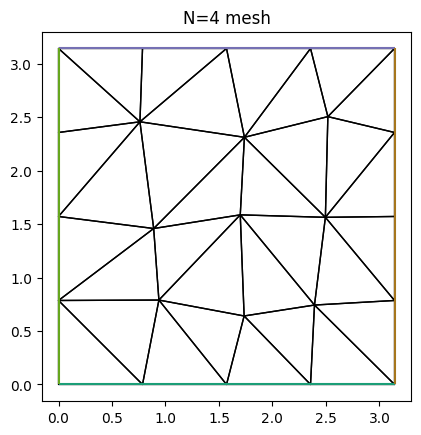


  Eigenvalue approximations and residual norms for petsctools_5_ solve.



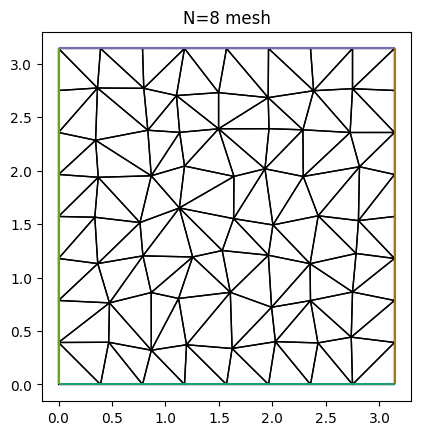


  Eigenvalue approximations and residual norms for petsctools_6_ solve.
  1 EPS nconv=6 first unconverged value (error) 15.6464 (7.70452368e-08)
  2 EPS nconv=10 first unconverged value (error) 23.6338 (5.99740559e-08)



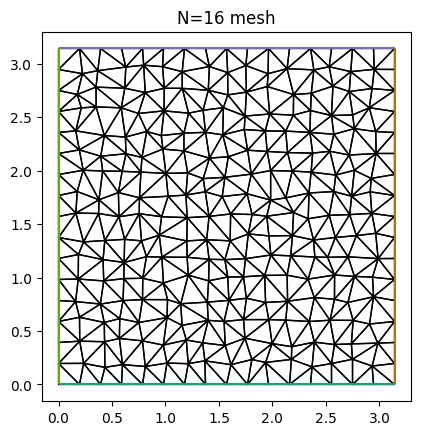


  Eigenvalue approximations and residual norms for petsctools_7_ solve.
  1 EPS nconv=4 first unconverged value (error) 10.3338 (4.33103105e-10)
  2 EPS nconv=8 first unconverged value (error) 17.9478 (4.95255912e-09)
  3 EPS nconv=12 first unconverged value (error) 21.5806 (2.06998730e-10)



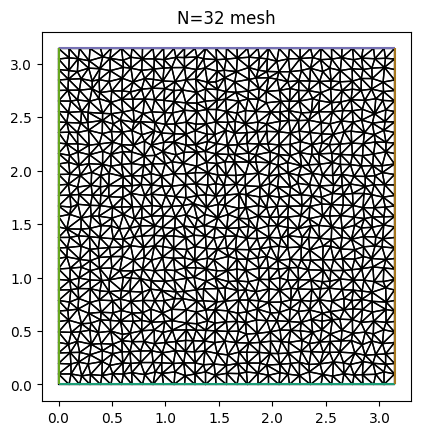


  Eigenvalue approximations and residual norms for petsctools_8_ solve.
  1 EPS nconv=4 first unconverged value (error) 10.0884 (1.09351750e-08)
  2 EPS nconv=8 first unconverged value (error) 17.2483 (2.40721453e-05)
  3 EPS nconv=11 first unconverged value (error) 20.3718 (1.50935047e-09)



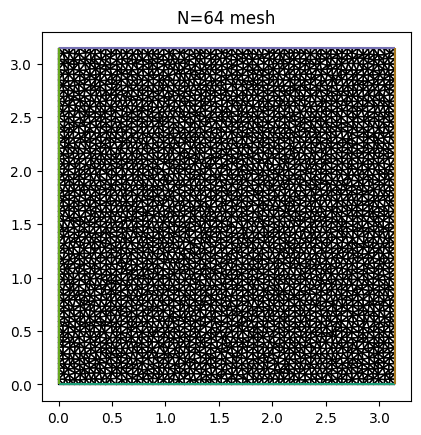


  Eigenvalue approximations and residual norms for petsctools_9_ solve.
  1 EPS nconv=4 first unconverged value (error) 10.0217 (3.77349616e-09)
  2 EPS nconv=8 first unconverged value (error) 17.0607 (8.04682169e-06)
  3 EPS nconv=11 first unconverged value (error) 20.0933 (8.78819350e-09)


In [10]:
eigvals = []
dof = []
N_vals = [4, 8, 16, 32, 64]

for N in N_vals:

    # mesh
    curr_mesh = unstructured_square(N)
    mesh = Mesh(curr_mesh)

    # plot
    print()
    triplot(mesh)
    plt.gca().set_aspect("equal")
    plt.title("N=" + str(N) + " mesh")
    plt.show()
    print()

    # mesh coordinate
    x = SpatialCoordinate(mesh)[0]

    # Space
    V = FunctionSpace(mesh, 'CG', 1)


    # Set the weak form
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(grad(u), grad(v))*dx
    b = inner(u, v)*dx


    # Boundary conditions and problem
    bc = DirichletBC(V, 0, "on_boundary")
    eigenproblem = LinearEigenproblem(a, b, bc)

    # The dof
    # Dirichlet conditions so subtract off boundary nodes
    dof.append( V.dim() - len(np.unique(bc.nodes)) )

    # Set the solver
    sp = {
              "eps_gen_hermitian": None,  # kind of problem
              "eps_smallest_real": None,  # which eigenvalues
              "eps_monitor": None,        # monitor
              "eps_type": "krylovschur",  # algorithm
              "eps_target": 0,            # shift parameter
              "st_type": "sinvert",       # shift-and-invert
              }

    eigensolver = LinearEigensolver(eigenproblem, 10, solver_parameters=sp)
    nconv = eigensolver.solve()  # number of converged eigenvalues

    # Pull out the real parts of the eigenvalues and eigenfuncs
    eigenvalues = [eigensolver.eigenvalue(i).real for i in range(nconv)]
    eigenfuncs  = [eigensolver.eigenfunction(i)[0] for i in range(nconv)]

    # save
    eigvals.append(eigenvalues)

In [11]:
# Table

rows = []

# loop over eigenvalues (k)
for k in range(9):

    row = {"Exact": exact[k]}

    # loop over meshes
    for j, N in enumerate(N_vals):

        # take kth eigenvalue on jth mesh
        lam = eigvals[j][k]

        # compute the rate
        if j == 0:
            row[f"N = {N}"] = f"{lam:.4f}"

        else:
            err_old = abs(eigvals[j-1][k] - exact[k]) # error on last mesh
            err_new = abs(eigvals[j][k] - exact[k]) # error on current mesh
            # assumes error(N) ~ C N^{-p} and we compute p
            # so we compute slope of log-log plot of error vs. N.
            rate = np.log(err_old / err_new) / np.log(N_vals[j] / N_vals[j-1])

            row[f"N = {N}"] = f"{lam:.4f} ({rate:.1f})"

    rows.append(row)


# dof row
dof_row = {"Exact": "DOF"}
for N, d in zip(N_vals, dof):
    dof_row[f"N = {N}"] = d
rows.append(dof_row)


# print
df = pd.DataFrame(rows)
df

,Exact,N = 4,N = 8,N = 16,N = 32,N = 64
0,2,2.2612,2.0651 (2.0),2.0163 (2.0),2.0040 (2.0),2.0010 (2.0)
1,5,6.3563,5.3603 (1.9),5.0922 (2.0),5.0232 (2.0),5.0058 (2.0)
2,5,6.6717,5.4306 (2.0),5.0937 (2.2),5.0238 (2.0),5.0058 (2.0)
3,8,11.5549,9.1348 (1.6),8.2588 (2.1),8.0656 (2.0),8.0161 (2.0)
4,10,14.2707,11.4326 (1.6),10.3338 (2.1),10.0884 (1.9),10.0217 (2.0)
5,10,15.9463,11.6468 (1.9),10.3534 (2.2),10.0894 (2.0),10.0220 (2.0)
6,13,20.7167,15.6464 (1.5),13.6691 (2.0),13.1665 (2.0),13.0412 (2.0)
7,13,24.7421,15.8234 (2.1),13.6798 (2.1),13.1702 (2.0),13.0414 (2.0)
8,17,31.8372,20.9448 (1.9),17.9478 (2.1),17.2483 (1.9),17.0607 (2.0)
9,DOF,9,49,225,961,3969


## Structured Squares

In [12]:
# Loop over N values

N_vals = [4, 8, 16, 32, 64]
eigvals = []
dof = []

for N in N_vals:

    # mesh
    mesh = SquareMesh(N, N, pi)

    # mesh coordinate
    x = SpatialCoordinate(mesh)[0]

    # Space
    V = FunctionSpace(mesh, 'CG', 1)


    # Set the weak form
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(grad(u), grad(v))*dx
    b = inner(u, v)*dx


    # Boundary conditions and problem
    bc = DirichletBC(V, 0, "on_boundary")
    eigenproblem = LinearEigenproblem(a, b, bc)

    # The dof
    # Dirichlet conditions so subtract off boundary nodes
    dof.append( V.dim() - len(np.unique(bc.nodes)) )

    # Set the solver
    sp = {
              "eps_gen_hermitian": None,  # kind of problem
              "eps_smallest_real": None,  # which eigenvalues
              "eps_monitor": None,        # monitor
              "eps_type": "krylovschur",  # algorithm
              "eps_target": 0,            # shift parameter
              "st_type": "sinvert",       # shift-and-invert
              }

    eigensolver = LinearEigensolver(eigenproblem, 10, solver_parameters=sp)
    nconv = eigensolver.solve()  # number of converged eigenvalues

    # Pull out the real parts of the eigenvalues and eigenfuncs
    eigenvalues = [eigensolver.eigenvalue(i).real for i in range(nconv)]
    eigenfuncs  = [eigensolver.eigenfunction(i)[0] for i in range(nconv)]

    # save
    eigvals.append(eigenvalues)

  Eigenvalue approximations and residual norms for petsctools_11_ solve.
  Eigenvalue approximations and residual norms for petsctools_13_ solve.
  1 EPS nconv=6 first unconverged value (error) 15.2271 (1.16977710e-09)
  2 EPS nconv=11 first unconverged value (error) 26.6985 (9.26961054e-10)
  Eigenvalue approximations and residual norms for petsctools_15_ solve.
  1 EPS nconv=4 first unconverged value (error) 10.3814 (1.27607389e-08)
  2 EPS nconv=8 first unconverged value (error) 18.0416 (8.06881561e-08)
  3 EPS nconv=13 first unconverged value (error) 27.0496 (6.65903313e-07)
  Eigenvalue approximations and residual norms for petsctools_17_ solve.
  1 EPS nconv=4 first unconverged value (error) 10.0949 (1.04339472e-06)
  2 EPS nconv=8 first unconverged value (error) 17.2562 (1.94603295e-05)
  3 EPS nconv=11 first unconverged value (error) 20.4239 (7.52614784e-09)
  Eigenvalue approximations and residual norms for petsctools_19_ solve.
  1 EPS nconv=4 first unconverged value (error) 

In [13]:
# Table

rows = []

# loop over eigenvalues (k)
for k in range(9):

    row = {"Exact": exact[k]}

    # loop over meshes
    for j, N in enumerate(N_vals):

        # take kth eigenvalue on jth mesh
        lam = eigvals[j][k]

        # compute the rate
        if j == 0:
            row[f"N = {N}"] = f"{lam:.4f}"

        else:
            err_old = abs(eigvals[j-1][k] - exact[k]) # error on last mesh
            err_new = abs(eigvals[j][k] - exact[k]) # error on current mesh
            # assumes error(N) ~ C N^{-p} and we compute p
            # so we compute slope of log-log plot of error vs. N.
            rate = np.log(err_old / err_new) / np.log(N_vals[j] / N_vals[j-1])

            row[f"N = {N}"] = f"{lam:.4f} ({rate:.1f})"

    rows.append(row)

# dof row
dof_row = {"Exact": "DOF"}
for N, d in zip(N_vals, dof):
    dof_row[f"N = {N}"] = d
rows.append(dof_row)


# print
df = pd.DataFrame(rows)
df

,Exact,N = 4,N = 8,N = 16,N = 32,N = 64
0,2,2.3168,2.0776 (2.0),2.0193 (2.0),2.0048 (2.0),2.0012 (2.0)
1,5,6.3387,5.3325 (2.0),5.0829 (2.0),5.0207 (2.0),5.0052 (2.0)
2,5,7.2502,5.5325 (2.1),5.1302 (2.0),5.0324 (2.0),5.0081 (2.0)
3,8,12.2145,9.1826 (1.8),8.3054 (2.0),8.0769 (2.0),8.0193 (2.0)
4,10,15.5629,11.5492 (1.8),10.3814 (2.0),10.0949 (2.0),10.0237 (2.0)
5,10,16.7643,11.6879 (2.0),10.3900 (2.1),10.0955 (2.0),10.0237 (2.0)
6,13,20.8965,15.2271 (1.8),13.5716 (2.0),13.1443 (2.0),13.0362 (2.0)
7,13,26.0989,17.0125 (1.7),13.9825 (2.0),13.2432 (2.0),13.0606 (2.0)
8,17,32.4184,21.3374 (1.8),18.0416 (2.1),17.2562 (2.0),17.0638 (2.0)
9,DOF,9,49,225,961,3969


## Reverse Diagonal

In [14]:
# Loop over N values

N_vals = [4, 8, 16, 32, 64]
eigvals = []
dof = []

for N in N_vals:

    # mesh
    # REVERSE THE DIAGONAL
    mesh = SquareMesh(N, N, pi, diagonal = "right")

    # mesh coordinate
    x = SpatialCoordinate(mesh)[0]

    # Space
    V = FunctionSpace(mesh, 'CG', 1)


    # Set the weak form
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(grad(u), grad(v))*dx
    b = inner(u, v)*dx


    # Boundary conditions and problem
    bc = DirichletBC(V, 0, "on_boundary")
    eigenproblem = LinearEigenproblem(a, b, bc)

    # The dof
    # Dirichlet conditions so subtract off boundary nodes
    dof.append( V.dim() - len(np.unique(bc.nodes)) )

    # Set the solver
    sp = {
              "eps_gen_hermitian": None,  # kind of problem
              "eps_smallest_real": None,  # which eigenvalues
              "eps_monitor": None,        # monitor
              "eps_type": "krylovschur",  # algorithm
              "eps_target": 0,            # shift parameter
              "st_type": "sinvert",       # shift-and-invert
              }

    eigensolver = LinearEigensolver(eigenproblem, 10, solver_parameters=sp)
    nconv = eigensolver.solve()  # number of converged eigenvalues

    # Pull out the real parts of the eigenvalues and eigenfuncs
    eigenvalues = [eigensolver.eigenvalue(i).real for i in range(nconv)]
    eigenfuncs  = [eigensolver.eigenfunction(i)[0] for i in range(nconv)]

    # save
    eigvals.append(eigenvalues)

  Eigenvalue approximations and residual norms for petsctools_21_ solve.
  Eigenvalue approximations and residual norms for petsctools_23_ solve.
  1 EPS nconv=6 first unconverged value (error) 15.2271 (1.16977710e-09)
  2 EPS nconv=11 first unconverged value (error) 26.6985 (9.26961054e-10)
  Eigenvalue approximations and residual norms for petsctools_25_ solve.
  1 EPS nconv=4 first unconverged value (error) 10.3814 (1.27607389e-08)
  2 EPS nconv=8 first unconverged value (error) 18.0416 (8.06881561e-08)
  3 EPS nconv=13 first unconverged value (error) 27.0496 (6.65903313e-07)
  Eigenvalue approximations and residual norms for petsctools_27_ solve.
  1 EPS nconv=4 first unconverged value (error) 10.0949 (1.04339472e-06)
  2 EPS nconv=8 first unconverged value (error) 17.2562 (1.94603295e-05)
  3 EPS nconv=11 first unconverged value (error) 20.4239 (7.52614784e-09)
  Eigenvalue approximations and residual norms for petsctools_29_ solve.
  1 EPS nconv=4 first unconverged value (error) 

In [15]:
# Table

rows = []

# loop over eigenvalues (k)
for k in range(9):

    row = {"Exact": exact[k]}

    # loop over meshes
    for j, N in enumerate(N_vals):

        # take kth eigenvalue on jth mesh
        lam = eigvals[j][k]

        # compute the rate
        if j == 0:
            row[f"N = {N}"] = f"{lam:.4f}"

        else:
            err_old = abs(eigvals[j-1][k] - exact[k]) # error on last mesh
            err_new = abs(eigvals[j][k] - exact[k]) # error on current mesh
            # assumes error(N) ~ C N^{-p} and we compute p
            # so we compute slope of log-log plot of error vs. N.
            rate = np.log(err_old / err_new) / np.log(N_vals[j] / N_vals[j-1])

            row[f"N = {N}"] = f"{lam:.4f} ({rate:.1f})"

    rows.append(row)

# dof row
dof_row = {"Exact": "DOF"}
for N, d in zip(N_vals, dof):
    dof_row[f"N = {N}"] = d
rows.append(dof_row)


# print
df = pd.DataFrame(rows)
df

,Exact,N = 4,N = 8,N = 16,N = 32,N = 64
0,2,2.3168,2.0776 (2.0),2.0193 (2.0),2.0048 (2.0),2.0012 (2.0)
1,5,6.3387,5.3325 (2.0),5.0829 (2.0),5.0207 (2.0),5.0052 (2.0)
2,5,7.2502,5.5325 (2.1),5.1302 (2.0),5.0324 (2.0),5.0081 (2.0)
3,8,12.2145,9.1826 (1.8),8.3054 (2.0),8.0769 (2.0),8.0193 (2.0)
4,10,15.5629,11.5492 (1.8),10.3814 (2.0),10.0949 (2.0),10.0237 (2.0)
5,10,16.7643,11.6879 (2.0),10.3900 (2.1),10.0955 (2.0),10.0237 (2.0)
6,13,20.8965,15.2271 (1.8),13.5716 (2.0),13.1443 (2.0),13.0362 (2.0)
7,13,26.0989,17.0125 (1.7),13.9825 (2.0),13.2432 (2.0),13.0606 (2.0)
8,17,32.4184,21.3374 (1.8),18.0416 (2.1),17.2562 (2.0),17.0638 (2.0)
9,DOF,9,49,225,961,3969


## Criss-Crossed Mesh

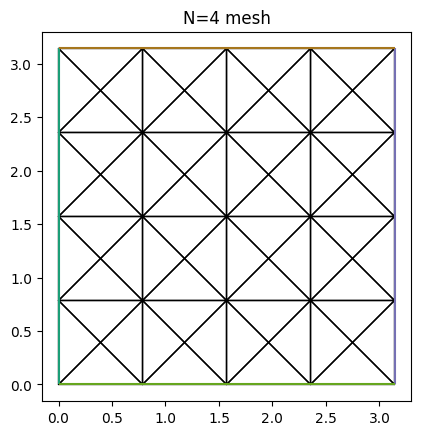


  Eigenvalue approximations and residual norms for petsctools_31_ solve.



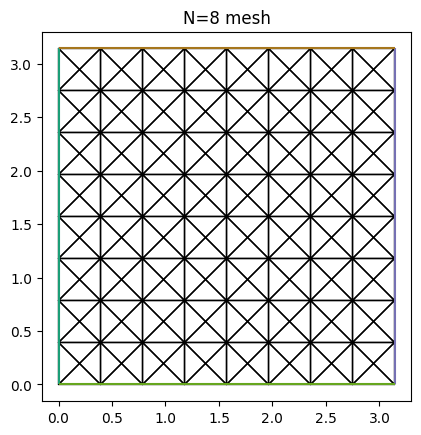


  Eigenvalue approximations and residual norms for petsctools_33_ solve.
  1 EPS nconv=1 first unconverged value (error) 5.16509 (7.68693639e-10)
  2 EPS nconv=6 first unconverged value (error) 14.0237 (4.48316739e-10)
  3 EPS nconv=8 first unconverged value (error) 19.3348 (2.30454052e-10)
  4 EPS nconv=11 first unconverged value (error) 22.7243 (3.45001284e-10)



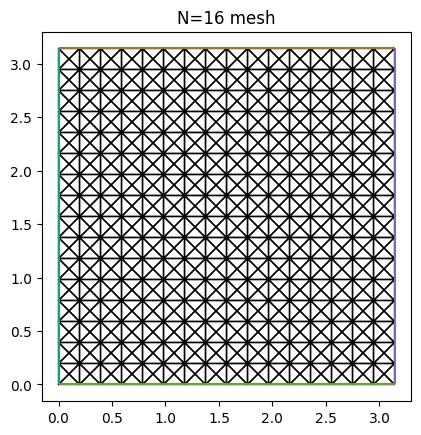


  Eigenvalue approximations and residual norms for petsctools_35_ solve.
  1 EPS nconv=2 first unconverged value (error) 5.04084 (3.26239929e-07)
  2 EPS nconv=4 first unconverged value (error) 10.1865 (2.67263856e-10)
  3 EPS nconv=9 first unconverged value (error) 17.5733 (6.04456555e-06)
  4 EPS nconv=12 first unconverged value (error) 20.6603 (3.40640264e-06)



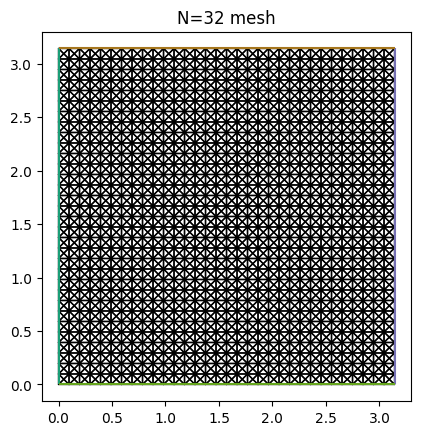


  Eigenvalue approximations and residual norms for petsctools_37_ solve.
  1 EPS nconv=1 first unconverged value (error) 5.01018 (1.39206445e-09)
  2 EPS nconv=5 first unconverged value (error) 10.0464 (1.09742222e-10)
  3 EPS nconv=9 first unconverged value (error) 17.1423 (5.94030662e-04)
  4 EPS nconv=9 first unconverged value (error) 17.1423 (6.32718460e-10)
  5 EPS nconv=14 first unconverged value (error) 25.2222 (6.42391223e-03)



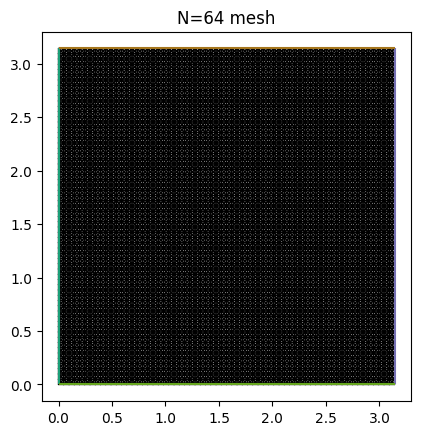


  Eigenvalue approximations and residual norms for petsctools_39_ solve.
  1 EPS nconv=1 first unconverged value (error) 5.00254 (1.98913512e-09)
  2 EPS nconv=7 first unconverged value (error) 13.0154 (9.71059118e-04)
  3 EPS nconv=7 first unconverged value (error) 13.0154 (1.79932325e-10)
  4 EPS nconv=11 first unconverged value (error) 20.0407 (3.29353265e-10)


In [16]:
# Loop over N values

N_vals = [4, 8, 16, 32, 64]
eigvals = []
dof = []

for N in N_vals:

    # mesh
    # CROSS THE DIAGONAL
    mesh = SquareMesh(N, N, pi, diagonal = "crossed")

    # plot
    print()
    triplot(mesh)
    plt.gca().set_aspect("equal")
    plt.title("N=" + str(N) + " mesh")
    plt.show()
    print()


    # mesh coordinate
    x = SpatialCoordinate(mesh)[0]

    # Space
    V = FunctionSpace(mesh, 'CG', 1)


    # Set the weak form
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(grad(u), grad(v))*dx
    b = inner(u, v)*dx


    # Boundary conditions and problem
    bc = DirichletBC(V, 0, "on_boundary")
    eigenproblem = LinearEigenproblem(a, b, bc)

    # The dof
    # Dirichlet conditions so subtract off boundary nodes
    dof.append( V.dim() - len(np.unique(bc.nodes)) )

    # Set the solver
    sp = {
              "eps_gen_hermitian": None,  # kind of problem
              "eps_smallest_real": None,  # which eigenvalues
              "eps_monitor": None,        # monitor
              "eps_type": "krylovschur",  # algorithm
              "eps_target": 0,            # shift parameter
              "st_type": "sinvert",       # shift-and-invert
              }

    eigensolver = LinearEigensolver(eigenproblem, 10, solver_parameters=sp)
    nconv = eigensolver.solve()  # number of converged eigenvalues

    # Pull out the real parts of the eigenvalues and eigenfuncs
    eigenvalues = [eigensolver.eigenvalue(i).real for i in range(nconv)]
    eigenfuncs  = [eigensolver.eigenfunction(i)[0] for i in range(nconv)]

    # save
    eigvals.append(eigenvalues)

In [17]:
# Table

rows = []

# loop over eigenvalues (k)
for k in range(9):

    row = {"Exact": exact[k]}

    # loop over meshes
    for j, N in enumerate(N_vals):

        # take kth eigenvalue on jth mesh
        lam = eigvals[j][k]

        # compute the rate
        if j == 0:
            row[f"N = {N}"] = f"{lam:.4f}"

        else:
            err_old = abs(eigvals[j-1][k] - exact[k]) # error on last mesh
            err_new = abs(eigvals[j][k] - exact[k]) # error on current mesh
            # assumes error(N) ~ C N^{-p} and we compute p
            # so we compute slope of log-log plot of error vs. N.
            rate = np.log(err_old / err_new) / np.log(N_vals[j] / N_vals[j-1])

            row[f"N = {N}"] = f"{lam:.4f} ({rate:.1f})"

    rows.append(row)


# dof row
dof_row = {"Exact": "DOF"}
for N, d in zip(N_vals, dof):
    dof_row[f"N = {N}"] = d
rows.append(dof_row)


# print
df = pd.DataFrame(rows)
df


,Exact,N = 4,N = 8,N = 16,N = 32,N = 64
0,2,2.0880,2.0216 (2.0),2.0054 (2.0),2.0013 (2.0),2.0003 (2.0)
1,5,5.6811,5.1651 (2.0),5.0408 (2.0),5.0102 (2.0),5.0025 (2.0)
2,5,5.6811,5.1651 (2.0),5.0408 (2.0),5.0102 (2.0),5.0025 (2.0)
3,8,9.4962,8.3521 (2.1),8.0863 (2.0),8.0215 (2.0),8.0054 (2.0)
4,10,12.9691,10.7578 (2.0),10.1865 (2.0),10.0464 (2.0),10.0116 (2.0)
5,10,12.9691,10.7578 (2.0),10.1865 (2.0),10.0464 (2.0),10.0116 (2.0)
6,13,17.1879,14.0237 (2.0),13.2489 (2.0),13.0617 (2.0),13.0154 (2.0)
7,13,17.1879,14.0237 (2.0),13.2489 (2.0),13.0617 (2.0),13.0154 (2.0)
8,17,25.1471,19.3348 (1.8),17.5733 (2.0),17.1423 (2.0),17.0355 (2.0)
9,DOF,25,113,481,1985,8065


## L - Shaped Domain

Next, we approximate nonsmooth solutions by considering an L-shaped domain. In particular, we consider a domain with a re-entrant corner and a sequence of unstructured meshes. The domain is a flipped L, with coordinates $(0, 0), (1, 0), (1, 1), (-1, 1), (-1, -1)$ and $(0, -1).$

Here, we solve the Neumann problem:
$$ - \nabla^2 u = \lambda u, \qquad (x, y) \in \Omega $$
with
$$ \frac{\partial u}{\partial n} = 0 \qquad \text{on} \, \partial \Omega.$$


The reference eigenvalues are $$\lambda \approx 0, 1.48, 3.53, 9.87, 11.39.$$

## The variational problem

Take $V = H^1(\Omega).$ We want to find a $\lambda \in \mathbb{R}$ and a nonzero $u \in V$ such that
$$ \int_{\Omega} \nabla u \cdot \nabla v \, dx dy = \lambda \int_{\Omega} u v \, dxdy $$
for all $v \in V.$

## Galerkin approximation

As before, we take solve for a solution in a finite dimensional subspace of $V,$ namely, the space of continuous piecewise linear finite elements. Thus, we want to
find a $\lambda_h \in \mathbb{R}$ and a nonzero $u_h \in V_h \subset V$ such that
$$ \int_{\Omega} \nabla u_h \cdot \nabla v \, dx dy = \lambda_h \int_{\Omega} u_h v \, dxdy $$
for all $v \in V_h \subset V.$

## Notes

* In the presence of singularities we expect (and observe) lower convergence rates. This is apparent in the first nonzero eigenvalue. However, the symmetry of the domain causes the other eigenvalues' convergence rates to be unaffected (smooth eigenfunctions).
* As before, the discrete eigenvalues approximate the continuous ones from above.
* Since we are considering a Neumann problem, there is a vanishing frequency (zero eigenvalue).
* To emphasize that the convergence rate of the eigenvalues is related to the smoothness of the corresponding eigenfnction, we considered non-adapted meshes. However, in practice, we can improve the convergence by adding more degrees of freedom where they are needed, i.e, in the problematic corner of the L-shaped domain.

In [18]:
# Code to construct L-shaped meshes (unstructured)

def unstructured_L(N):

    # left vertical rectangle: [-1,0] x [-1,1]
    rect1 = WorkPlane(Axes((-1, -1, 0), n=Z, h=X)).Rectangle(1, 2).Face()

    # upper-right rectangle: [0,1] x [0,1]
    rect2 = WorkPlane(Axes((0, 0, 0), n=Z, h=X)).Rectangle(1, 1).Face()

    # union gives L-shaped domain
    L = rect1 + rect2

    geo = OCCGeometry(L, dim=2)

    ngmesh = geo.GenerateMesh(maxh=2/N)

    mesh = Mesh(ngmesh)

    return mesh

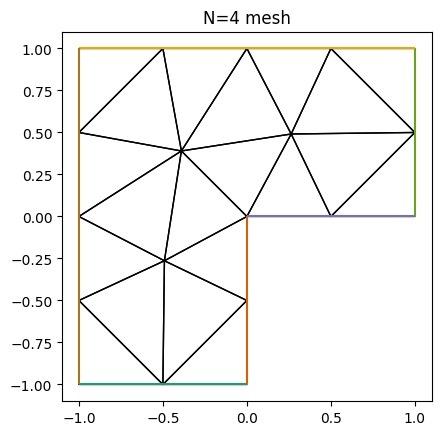


  Eigenvalue approximations and residual norms for petsctools_40_ solve.



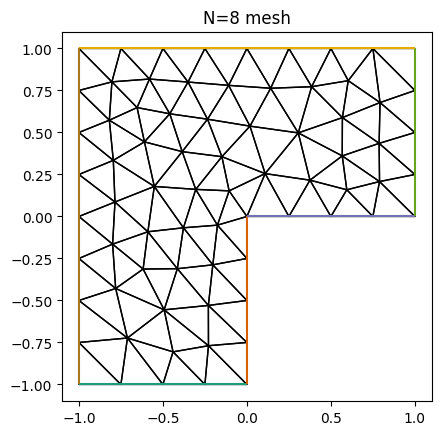


  Eigenvalue approximations and residual norms for petsctools_41_ solve.
  1 EPS nconv=3 first unconverged value (error) 10.2572 (7.20809733e-10)
  2 EPS nconv=10 first unconverged value (error) 32.5781 (6.77942121e-09)



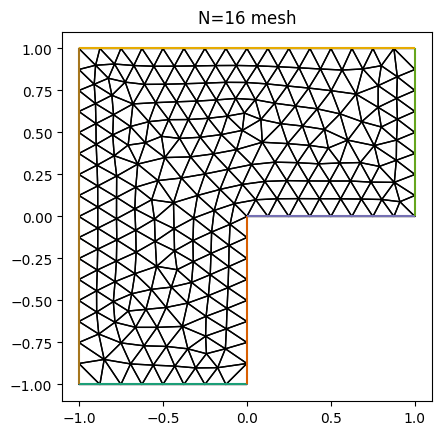


  Eigenvalue approximations and residual norms for petsctools_42_ solve.
  1 EPS nconv=3 first unconverged value (error) 9.97083 (7.90693330e-09)
  2 EPS nconv=9 first unconverged value (error) 23.8955 (3.20479386e-10)



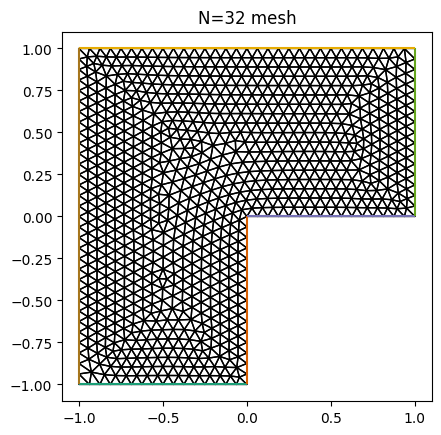


  Eigenvalue approximations and residual norms for petsctools_43_ solve.
  1 EPS nconv=3 first unconverged value (error) 9.8937 (3.51643378e-08)
  2 EPS nconv=9 first unconverged value (error) 23.4793 (7.05237043e-10)



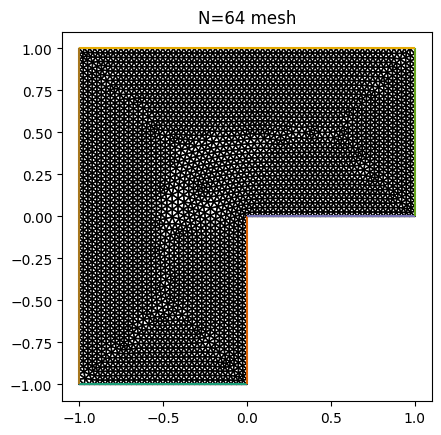


  Eigenvalue approximations and residual norms for petsctools_44_ solve.
  1 EPS nconv=3 first unconverged value (error) 9.87568 (1.18756474e-07)
  2 EPS nconv=9 first unconverged value (error) 23.3781 (1.94673087e-10)


In [19]:
# Mesh list
dof =[]
N_vals = [4, 8, 16, 32, 64]
eigvals = []

# Reference eigenvalues from Dauge 2003
# https://perso.univ-rennes1.fr/monique.dauge/benchmax.html#3.2DomA_EP
exact = [
    0.0,
    1.47562182408,
    3.53403136678,
    9.86960440109,
    9.86960440109,
    11.3894793979,]

# Loop over meshes
for N in N_vals:

    # construct the mesh\
    mesh = unstructured_L(N)

    # plot
    print()
    triplot(mesh)
    plt.gca().set_aspect("equal")
    plt.title("N=" + str(N) + " mesh")
    plt.show()
    print()

    # mesh coordinate
    x = SpatialCoordinate(mesh)[0]

    # Space
    V = FunctionSpace(mesh, 'CG', 1)

    # dof
    # neumann conditions so all nodes are free
    dof.append(V.dim())


    # Set the weak form
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(grad(u), grad(v))*dx
    b = inner(u, v)*dx


    # problem (neumann boundary conditions)
    eigenproblem = LinearEigenproblem(a, b)

    # Set the solver
    # Use a nonzero shift because A is singular (zero eigenvalue)
    sp = {
              "eps_gen_hermitian": None,  # kind of problem
              "eps_smallest_real": None,  # which eigenvalues
              "eps_monitor": None,        # monitor
              "eps_type": "krylovschur",  # algorithm
              "eps_target": 0.01,            # shift parameter
              "st_type": "sinvert",       # shift-and-invert
              }

    eigensolver = LinearEigensolver(eigenproblem, 6, solver_parameters=sp)
    nconv = eigensolver.solve()  # number of converged eigenvalues

    # Pull out the real parts of the eigenvalues and eigenfuncs
    eigenvalues = [eigensolver.eigenvalue(i).real for i in range(nconv)]
    eigenfuncs = [eigensolver.eigenfunction(i)[0] for i in range(nconv)]

    # save
    eigvals.append(eigenvalues)

In [20]:
# Table

rows = []

# loop over eigenvalues (k)
for k in range(6):

    row = {"Exact": exact[k]}

    # loop over meshes
    for j, N in enumerate(N_vals):

        # take kth eigenvalue on jth mesh
        lam = eigvals[j][k]

        # compute the rate
        if (j == 0):
            row[f"N = {N}"] = f"{lam:.4f}"

        elif (k==0):
            row[f"N = {N}"] = f"{lam:.4f}"

        else:
            err_old = abs(eigvals[j-1][k] - exact[k]) # error on last mesh
            err_new = abs(eigvals[j][k] - exact[k]) # error on current mesh
            # assumes error(N) ~ C N^{-p} and we compute p
            # so we compute slope of log-log plot of error vs. N.
            rate = np.log(err_old / err_new) / np.log(N_vals[j] / N_vals[j-1])

            row[f"N = {N}"] = f"{lam:.4f} ({rate:.1f})"


    rows.append(row)

# dof row
dof_row = {"Exact": "DOF"}
for N, d in zip(N_vals, dof):
    dof_row[f"N = {N}"] = d
rows.append(dof_row)


# print
df = pd.DataFrame(rows)
df

,Exact,N = 4,N = 8,N = 16,N = 32,N = 64
0,0.0,-0.0000,0.0000,-0.0000,-0.0000,0.0000
1,1.475622,1.6722,1.5263 (2.0),1.4941 (1.5),1.4825 (1.4),1.4782 (1.4)
2,3.534031,3.8370,3.5807 (2.7),3.5462 (1.9),3.5371 (2.0),3.5348 (2.0)
3,9.869604,12.0468,10.2572 (2.5),9.9708 (1.9),9.8937 (2.1),9.8757 (2.0)
4,9.869604,12.0985,10.2835 (2.4),9.9736 (2.0),9.8947 (2.0),9.8758 (2.0)
5,11.389479,14.5367,11.9605 (2.5),11.5314 (2.0),11.4224 (2.1),11.3976 (2.0)
6,DOF,19,74,248,936,3621


## Non-conforming elements

We now experiment with solving he Laplace eigenvalue problem on $(0, \pi) \times (0, \pi)$ with non-conforming elements.

Recall that if $V_h \subset V,$ then the approximation is conforming. Alternatively, if $V_h \not\subset V,$ then the approximation is non-conforming

As before, we will use a sequence of unstructured meshes on the square. However, now we will use linear non-conforming triangular elements, known as Crouzeix-Raviart elements.

## Notes
* As expected, we observeb the optimal quadratic rate of convergence in the eigenvalue computations
* However, now the computed eigenvalues are lower bounds on the exact eigenvalues. This is typical behaviour for non-conforming approximations and has been reported by several authors (see Boffi pg. 16).
* In general, conforming approximations of eigenvalues are always above the exact solutions, while nonconforming ones may be below.
* In mized approximations (next) there are situations where the same computation provides upper bounds for some eigenvalues and lower bounds for others.
* In Patrick's Oxford slides, he says that a conforming discretization of a symmetric coercive problem approximates the eigenvalues from above, while a nonconforming discretization, on a sufficiently fine mesh, approximates the eigenvalues from below.

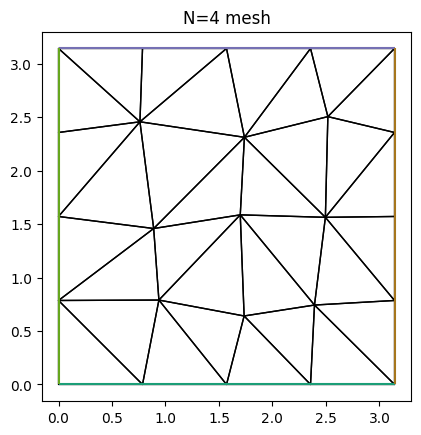


  Eigenvalue approximations and residual norms for petsctools_45_ solve.
  1 EPS nconv=3 first unconverged value (error) 7.28047 (2.35872877e-10)
  2 EPS nconv=11 first unconverged value (error) 13.233 (4.87529740e-10)



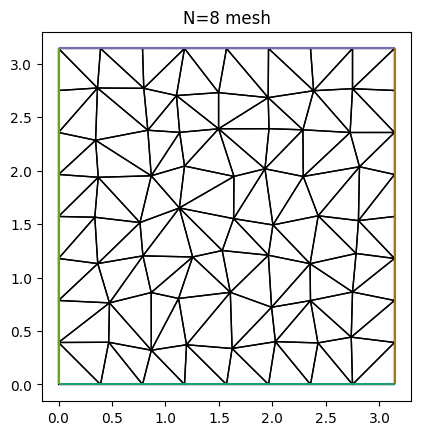


  Eigenvalue approximations and residual norms for petsctools_46_ solve.
  1 EPS nconv=4 first unconverged value (error) 9.40838 (2.30156698e-09)
  2 EPS nconv=8 first unconverged value (error) 15.2006 (3.04143688e-08)
  3 EPS nconv=11 first unconverged value (error) 18.1155 (1.64839917e-09)



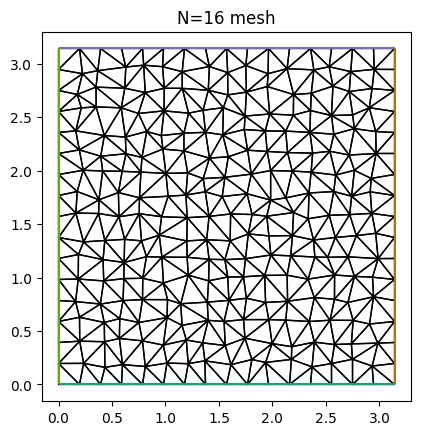


  Eigenvalue approximations and residual norms for petsctools_47_ solve.
  1 EPS nconv=4 first unconverged value (error) 9.86704 (4.50221421e-09)
  2 EPS nconv=8 first unconverged value (error) 16.5739 (4.40206151e-06)
  3 EPS nconv=11 first unconverged value (error) 19.5599 (1.53458071e-09)



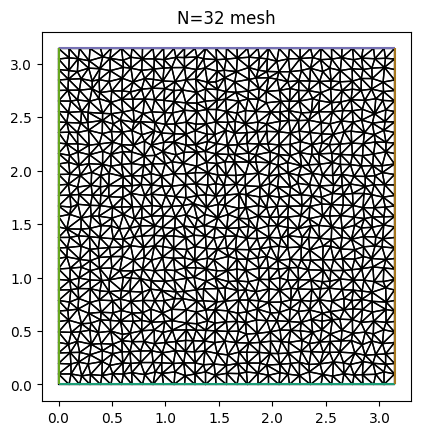


  Eigenvalue approximations and residual norms for petsctools_48_ solve.
  1 EPS nconv=4 first unconverged value (error) 9.96616 (1.52832540e-08)
  2 EPS nconv=6 first unconverged value (error) 12.9618 (1.16530810e-10)
  3 EPS nconv=11 first unconverged value (error) 19.89 (1.95584466e-08)



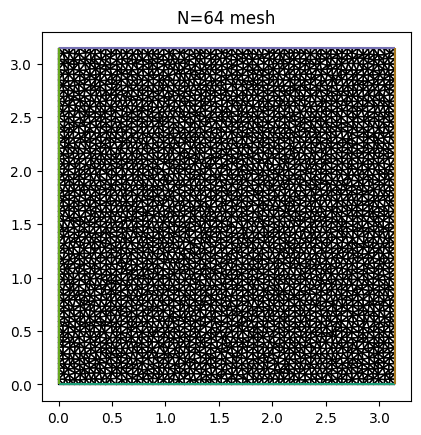


  Eigenvalue approximations and residual norms for petsctools_49_ solve.
  1 EPS nconv=4 first unconverged value (error) 9.99165 (3.33504060e-08)
  2 EPS nconv=8 first unconverged value (error) 16.9736 (7.56996048e-06)
  3 EPS nconv=11 first unconverged value (error) 19.9723 (1.56007245e-07)


In [21]:
eigvals = []
dof = []
N_vals = [4, 8, 16, 32, 64]
exact = [2, 5, 5, 8, 10, 10, 13, 13, 17, 17, 18, 20, 20, 25, 25, 26, 26]

for N in N_vals:

    # mesh
    curr_mesh = unstructured_square(N)
    mesh = Mesh(curr_mesh)

    # plot
    print()
    triplot(mesh)
    plt.gca().set_aspect("equal")
    plt.title("N=" + str(N) + " mesh")
    plt.show()
    print()

    # mesh coordinate
    x = SpatialCoordinate(mesh)[0]

    # Space
    V = FunctionSpace(mesh, 'CR', 1)


    # Set the weak form
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(grad(u), grad(v))*dx
    b = inner(u, v)*dx


    # Boundary conditions and problem
    bc = DirichletBC(V, 0, "on_boundary")
    eigenproblem = LinearEigenproblem(a, b, bc)

    # The dof
    # Dirichlet conditions so subtract off boundary nodes
    dof.append( V.dim() - len(np.unique(bc.nodes)) )

    # Set the solver
    sp = {
              "eps_gen_hermitian": None,  # kind of problem
              "eps_smallest_real": None,  # which eigenvalues
              "eps_monitor": None,        # monitor
              "eps_type": "krylovschur",  # algorithm
              "eps_target": 0,            # shift parameter
              "st_type": "sinvert",       # shift-and-invert
              }

    eigensolver = LinearEigensolver(eigenproblem, 10, solver_parameters=sp)
    nconv = eigensolver.solve()  # number of converged eigenvalues

    # Pull out the real parts of the eigenvalues and eigenfuncs
    eigenvalues = [eigensolver.eigenvalue(i).real for i in range(nconv)]
    eigenfuncs  = [eigensolver.eigenfunction(i)[0] for i in range(nconv)]

    # save
    eigvals.append(eigenvalues)

In [22]:
# Table

rows = []

# loop over eigenvalues (k)
for k in range(9):

    row = {"Exact": exact[k]}

    # loop over meshes
    for j, N in enumerate(N_vals):

        # take kth eigenvalue on jth mesh
        lam = eigvals[j][k]

        # compute the rate
        if j == 0:
            row[f"N = {N}"] = f"{lam:.4f}"

        else:
            err_old = abs(eigvals[j-1][k] - exact[k]) # error on last mesh
            err_new = abs(eigvals[j][k] - exact[k]) # error on current mesh
            # assumes error(N) ~ C N^{-p} and we compute p
            # so we compute slope of log-log plot of error vs. N.
            rate = np.log(err_old / err_new) / np.log(N_vals[j] / N_vals[j-1])

            row[f"N = {N}"] = f"{lam:.4f} ({rate:.1f})"

    rows.append(row)


# dof row
dof_row = {"Exact": "DOF"}
for N, d in zip(N_vals, dof):
    dof_row[f"N = {N}"] = d
rows.append(dof_row)


# print
df = pd.DataFrame(rows)
df

,Exact,N = 4,N = 8,N = 16,N = 32,N = 64
0,2,1.9686,1.9899 (1.6),1.9970 (1.7),1.9992 (2.0),1.9998 (2.0)
1,5,4.5845,4.8910 (1.9),4.9730 (2.0),4.9931 (2.0),4.9983 (2.0)
2,5,4.6170,4.9026 (2.0),4.9732 (1.9),4.9933 (2.0),4.9983 (2.0)
3,8,7.2805,7.8294 (2.1),7.9521 (1.8),7.9877 (2.0),7.9968 (1.9)
4,10,7.5094,9.4084 (2.1),9.8670 (2.2),9.9662 (2.0),9.9917 (2.0)
5,10,7.9372,9.4526 (1.9),9.8699 (2.1),9.9668 (2.0),9.9917 (2.0)
6,13,9.2454,12.3977 (2.6),12.8439 (1.9),12.9618 (2.0),12.9902 (2.0)
7,13,9.8048,12.4424 (2.5),12.8565 (2.0),12.9626 (1.9),12.9904 (2.0)
8,17,10.7888,15.2006 (1.8),16.5739 (2.1),16.8914 (2.0),16.9736 (2.0)
9,DOF,40,176,736,3008,12160


# Mixed Laplace Eigenvalue Problem